<a href="https://colab.research.google.com/github/consuelosimon/Consuelo-Simon-Taller/blob/main/T1_wooldridge_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El presente trabajo tiene como objetivo analizar la relación entre los salarios de los jugadores de la NBA y su desempeño deportivo, utilizando herramientas econométricas y datos provenientes de la base de dato de *nbasal* del paquete *wooldridge*.

In [5]:
# Instalación de paquetes
if (!require(wooldridge)) install.packages("wooldridge")
if (!require(ggplot2))    install.packages("ggplot2")
if (!require(lmtest))     install.packages("lmtest")
if (!require(sandwich))   install.packages("sandwich")
if (!require(car))        install.packages("car")
if (!require(nortest))    install.packages("nortest")
if (!require(corrplot))   install.packages("corrplot")

library(wooldridge)
library(ggplot2)
library(lmtest)
library(sandwich)
library(car)
library(nortest)
library(corrplot)

# Cargar la base de datos nbasal
data("nbasal")
nbasal <- na.omit(nbasal)


### 1. Descripción de la base de datos `nbasal`

El conjunto de datos `nbasal` proviene del paquete `wooldridge`, que contiene datos utilizados en el libro de texto *Introductory Econometrics: A Modern Approach* de Jeffrey M. Wooldridge. Este dataset es ampliamente usado para el análisis de determinación de salarios en el mercado deportivo profesional.

Contiene información sobre jugadores de la **NBA (National Basketball Association)** correspondiente a los registros de contratos de la temporada **1994-1995**. Es una muestra **transversal**, ya que recoge observaciones de múltiples individuos en un único período de tiempo. En total, el conjunto de datos contiene 269 observaciones y 22 variables, que permiten analizar la relación entre desempeño deportivo, características individuales y remuneraciones en un mercado laboral altamente competitivo.

**Origen:**  Base de datos recopilada por Wooldridge a partir de estadísticas oficiales de la NBA y registros de contratos de la temporada 1994-95.

**Variables principales:**

*- Variable Dependiente (Y):*
*   `wage`: Salario anual del jugador en miles de dólares.
*   `lwage`: Logaritmo natural del salario en miles de dólares.

*- Variable Independiente (X):*
*   `points`: Puntos totales anotados en la temporada.
*   `rebounds`: Rebotes totales capturados en la temporada.
*   `assists`: Asistencias totales en la temporada.
*   `exper`: Años de experiencia en la NBA.
*   `age`: Edad del jugador en años.

*- Variable Dummy o Dicotómica:*
*   `allstar`: 1 si el jugador fue All-Star.

Estas variables permiten analizar cómo distintos factores de desempeño y características individuales influyen en la determinación de los salarios en la NBA.

A continuación, se muestra la estructura y los nombres de las variables en el dataset.

In [8]:
# Variables y estructura
data("nbasal")
str(nbasal)

'data.frame':	269 obs. of  22 variables:
 $ marr    : int  1 1 0 0 0 0 1 0 1 1 ...
 $ wage    : num  1002 2030 650 2030 755 ...
 $ exper   : int  4 5 1 5 3 9 1 3 1 12 ...
 $ age     : int  27 28 25 28 24 31 28 27 25 35 ...
 $ coll    : int  4 4 4 4 4 4 0 3 4 3 ...
 $ games   : int  77 78 74 47 82 82 80 67 60 74 ...
 $ minutes : int  2867 2789 1149 1178 2096 1971 2303 1131 542 2700 ...
 $ guard   : int  1 1 0 0 1 0 0 0 1 0 ...
 $ forward : int  0 0 0 1 0 1 1 1 0 1 ...
 $ center  : int  0 0 1 0 0 0 0 0 0 0 ...
 $ points  : num  15.5 13.3 5.5 7.3 10.8 ...
 $ rebounds: num  3.9 2.5 3.3 5.1 4.3 ...
 $ assists : num  4.5 8.8 0.2 1.5 2.6 ...
 $ draft   : int  19 28 19 1 24 4 40 47 NA 3 ...
 $ allstar : int  0 0 0 0 0 0 0 0 0 1 ...
 $ avgmin  : num  37.2 35.8 15.5 25.1 25.6 ...
 $ lwage   : num  6.91 7.62 6.48 7.62 6.63 ...
 $ black   : int  1 1 1 1 1 1 0 1 1 1 ...
 $ children: int  0 1 0 0 0 0 0 0 0 1 ...
 $ expersq : int  16 25 1 25 9 81 1 9 1 144 ...
 $ agesq   : int  729 784 625 784 576 96

### 2. Medidas de tendencia central y dispersión de las variables clave

Se presentan las estadísticas descriptivas de las variables principales de la base de datos, con el objetivo de entender mejor su comportamiento. Para ello, se analizan medidas de tendencia central como la media y la mediana, así como medidas de dispersión, incluyendo la desviación estándar, los valores mínimo y máximo, y los cuartiles (Q1 y Q3).

Este análisis es importante, ya que facilita la comprensión de los datos antes de aplicar modelos econométricos más complejos.

      marr             wage          exper             age       
 Min.   :0.0000   Min.   : 150   Min.   : 1.000   Min.   :21.00  
 1st Qu.:0.0000   1st Qu.: 650   1st Qu.: 2.000   1st Qu.:25.00  
 Median :0.0000   Median :1186   Median : 4.000   Median :27.00  
 Mean   :0.4424   Mean   :1424   Mean   : 5.119   Mean   :27.39  
 3rd Qu.:1.0000   3rd Qu.:2014   3rd Qu.: 7.000   3rd Qu.:30.00  
 Max.   :1.0000   Max.   :5740   Max.   :18.000   Max.   :41.00  
                                                                 
      coll           games          minutes         guard       
 Min.   :0.000   Min.   : 3.00   Min.   :  33   Min.   :0.0000  
 1st Qu.:4.000   1st Qu.:57.00   1st Qu.: 983   1st Qu.:0.0000  
 Median :4.000   Median :74.00   Median :1690   Median :0.0000  
 Mean   :3.717   Mean   :65.72   Mean   :1682   Mean   :0.4201  
 3rd Qu.:4.000   3rd Qu.:79.00   3rd Qu.:2438   3rd Qu.:1.0000  
 Max.   :4.000   Max.   :82.00   Max.   :3533   Max.   :1.0000  
                 

         Variable   Media Mediana Desv_Est Asimetria Minimo     Q1      Q3
wage         wage 1423.83 1186.00   999.77      0.95 150.00 650.00 2014.50
lwage       lwage    6.95    7.08     0.88     -0.75   5.01   6.48    7.61
points     points   10.21    9.30     5.90      0.66   1.20   5.40   14.20
rebounds rebounds    4.40    3.80     2.89      1.25   0.50   2.30    5.50
assists   assists    2.41    1.90     2.09      1.67   0.00   0.90    3.40
exper       exper    5.12    4.00     3.40      0.81   1.00   2.00    7.00
age           age   27.39   27.00     3.39      0.76  21.00  25.00   30.00
allstar   allstar    0.12    0.00     0.32      2.40   0.00   0.00    0.00
          Maximo
wage     5740.00
lwage       8.66
points     29.80
rebounds   17.30
assists    12.60
exper      18.00
age        41.00
allstar     1.00


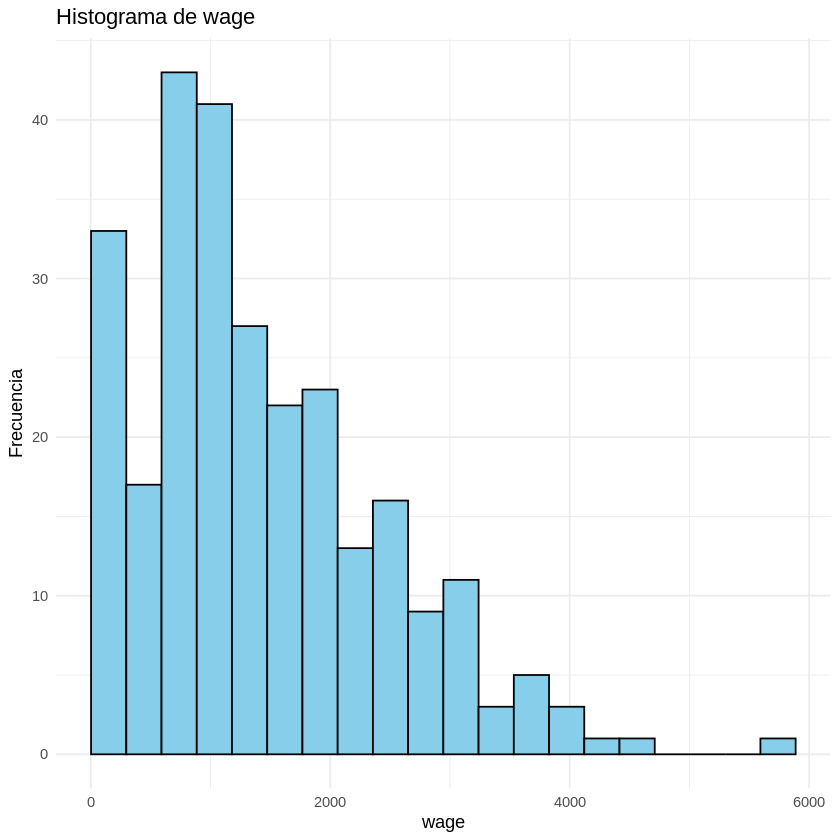

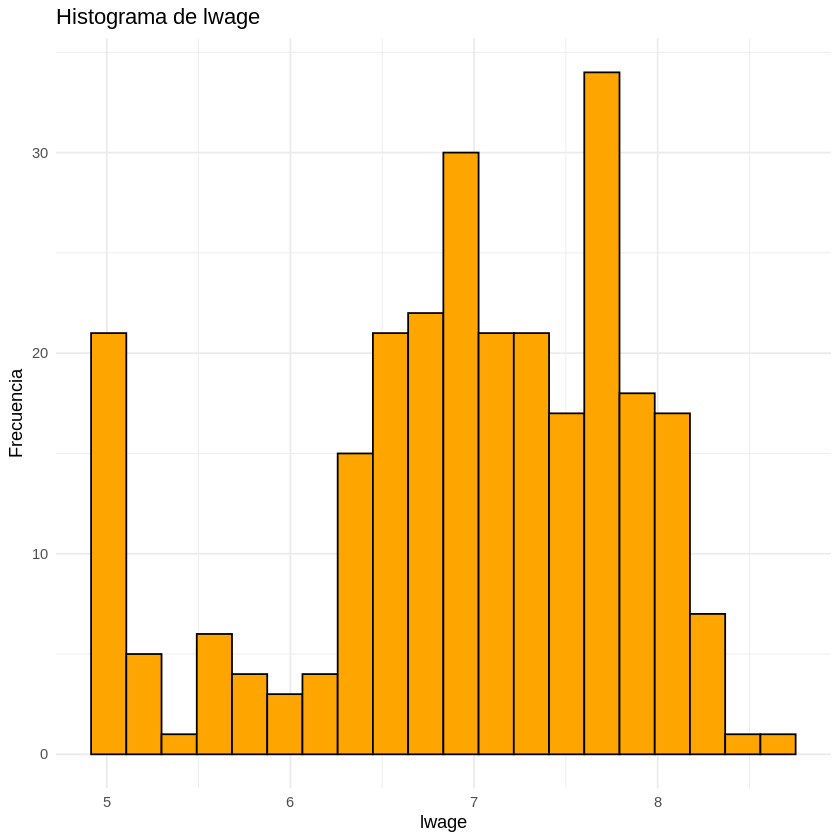

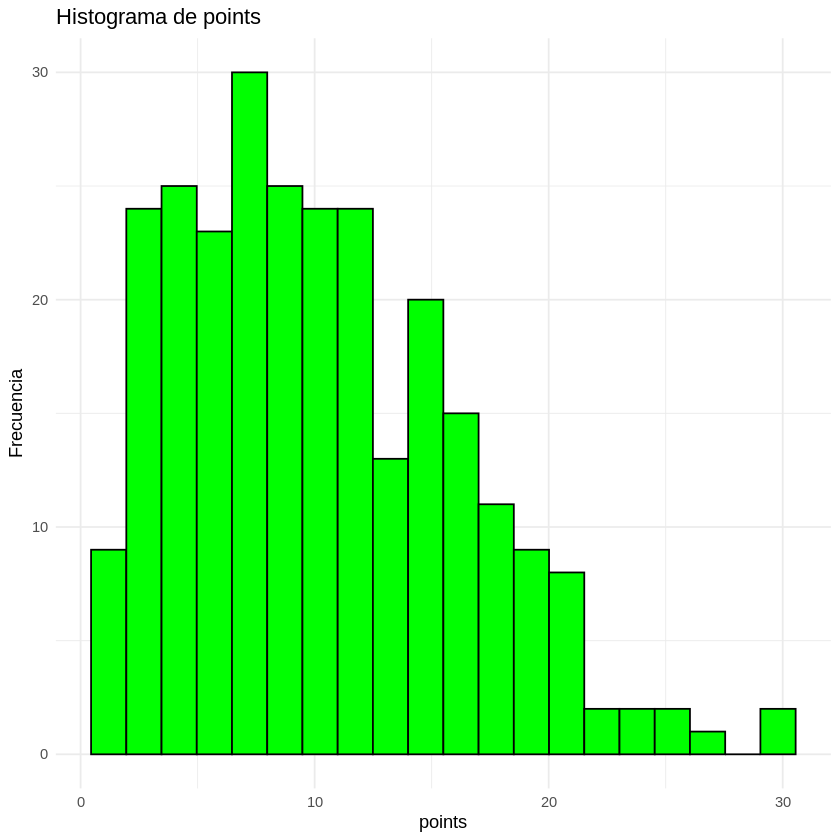

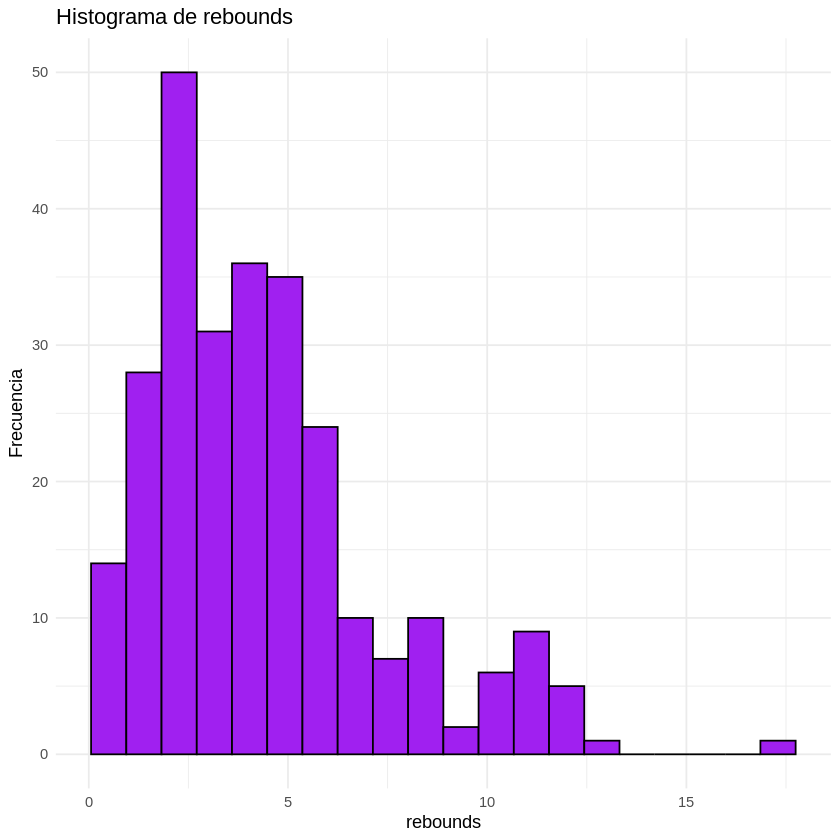

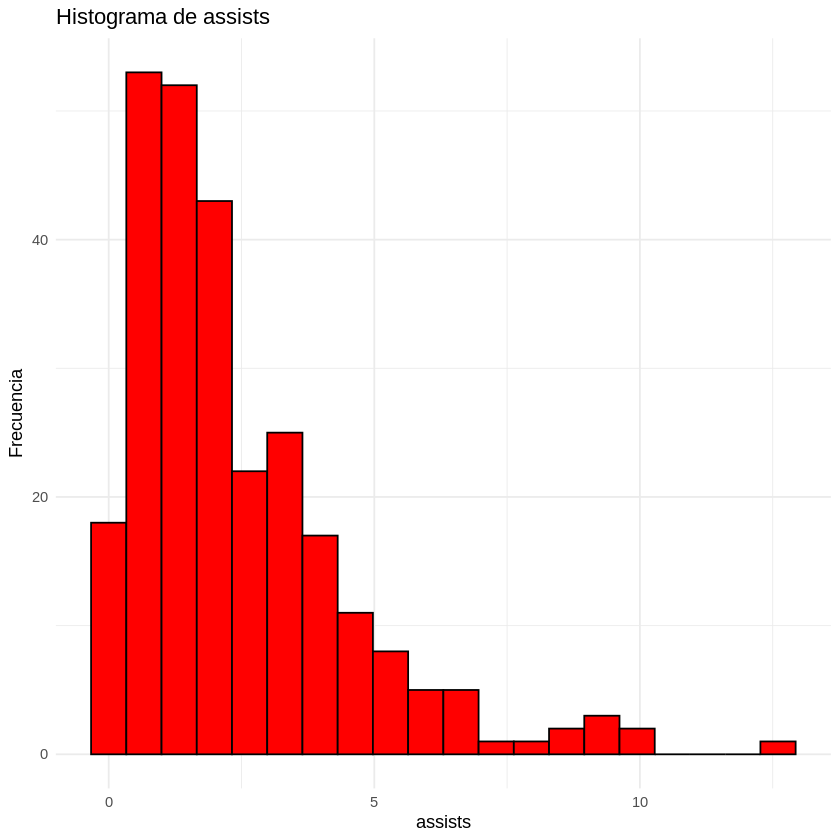

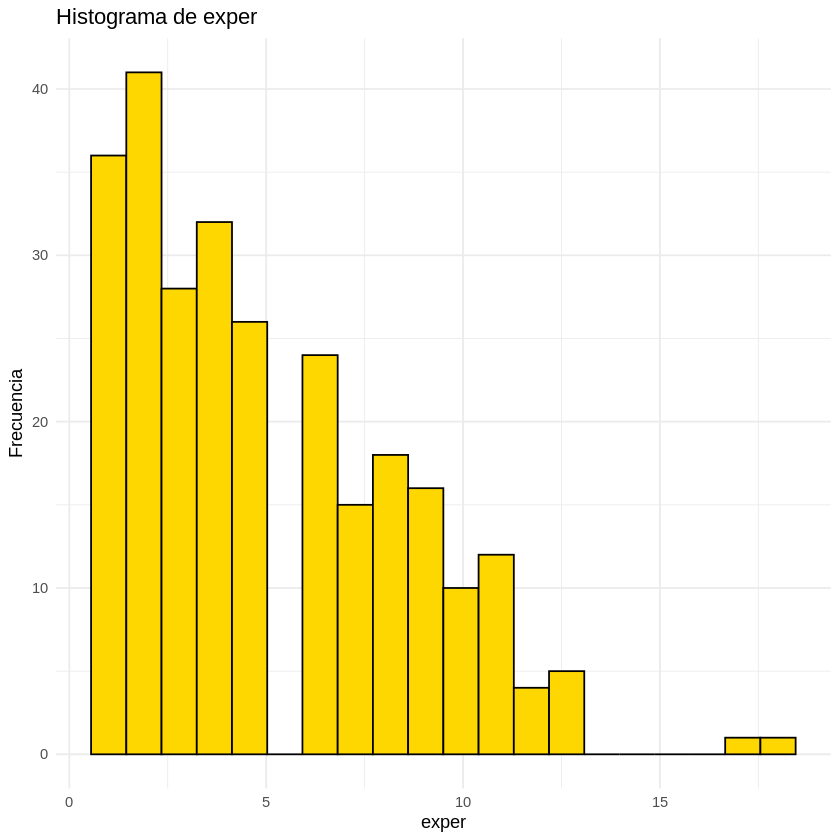

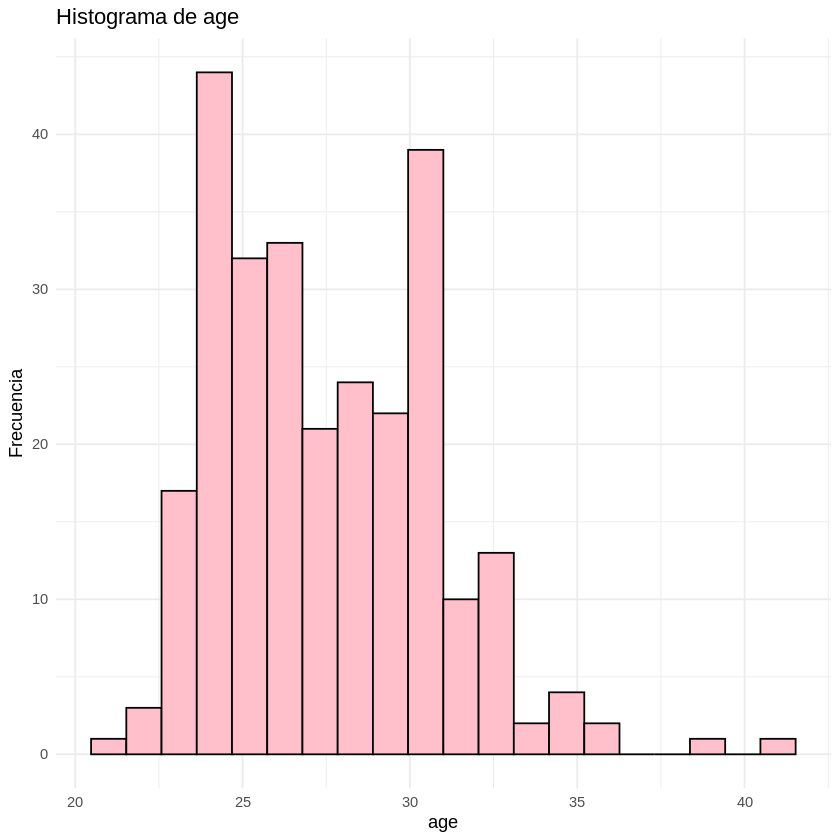

`geom_smooth()` using formula = 'y ~ x'


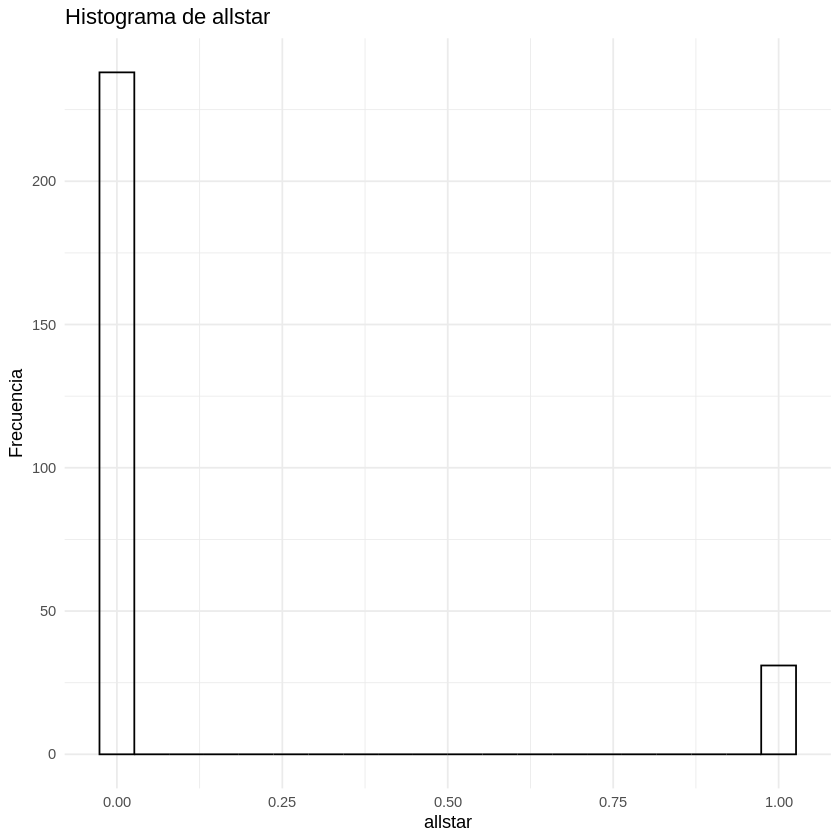

`geom_smooth()` using formula = 'y ~ x'


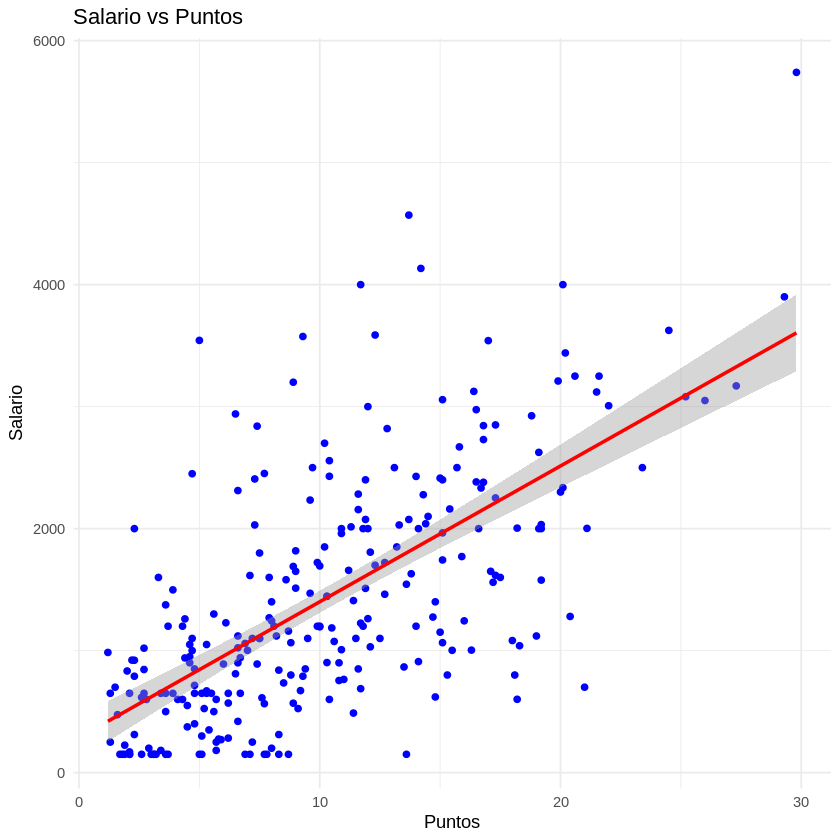

`geom_smooth()` using formula = 'y ~ x'


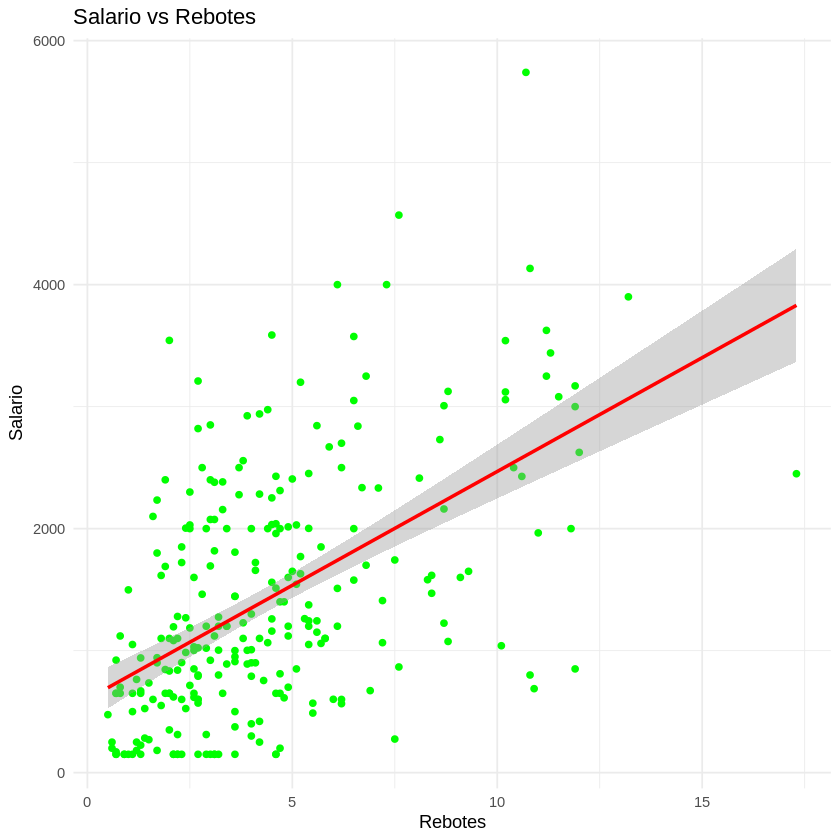

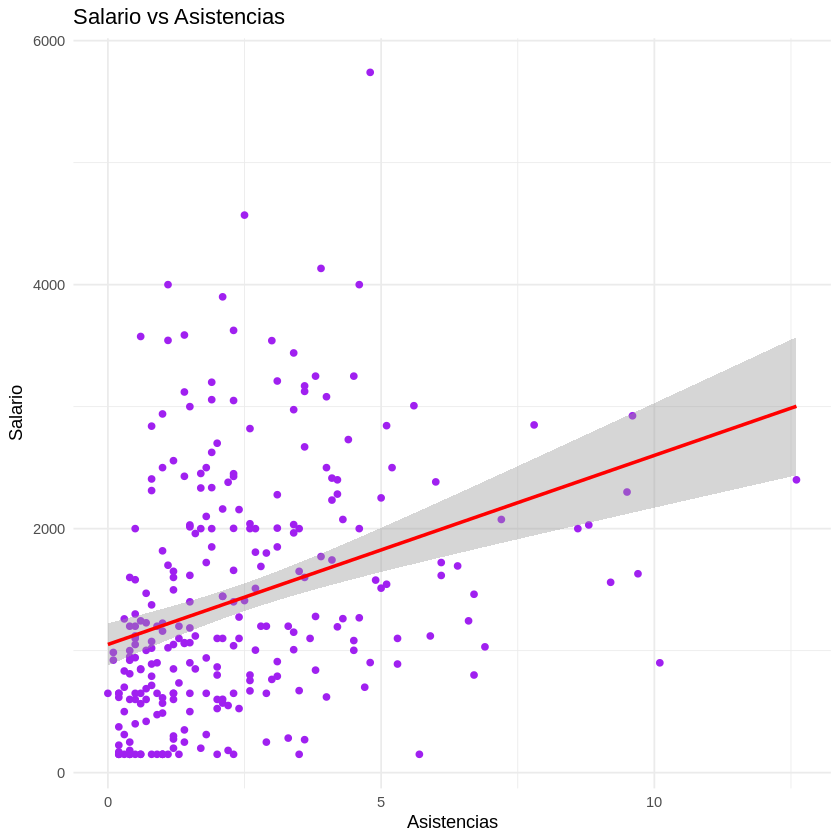

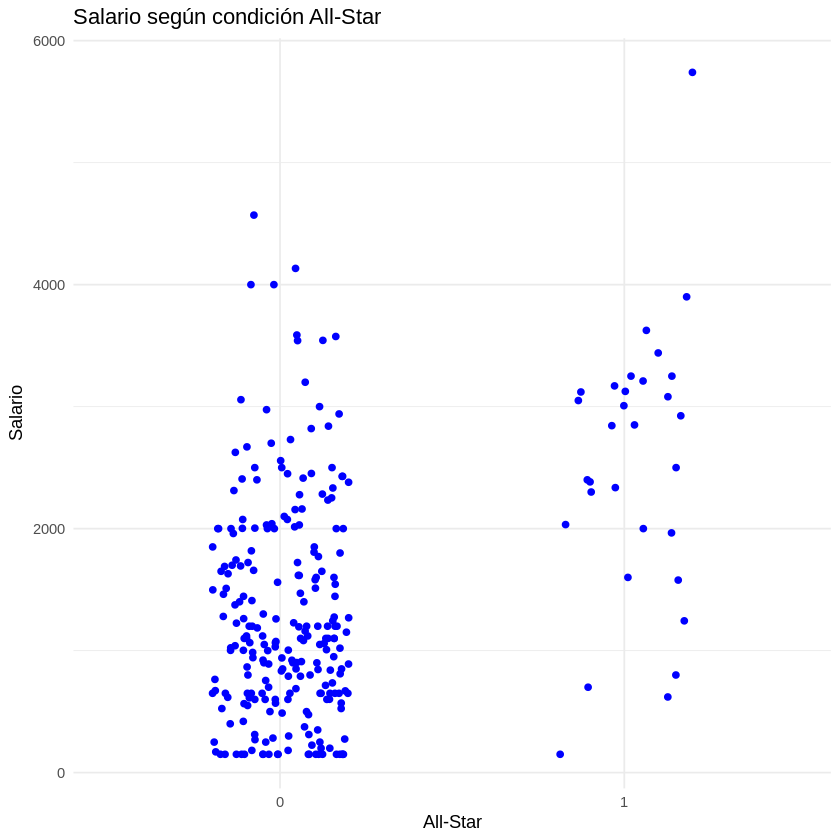

In [19]:
# Resumen estadístico completo del dataset
summary(nbasal)

# Crear variable logaritmo del salario
nbasal$lwage <- log(nbasal$wage)

# Tabla de estadísticas detalladas para variables clave
vars_key <- c("wage", "lwage", "points", "rebounds", "assists", "exper", "age", "allstar")

tabla_desc <- data.frame(
  Variable = vars_key,
  Media    = round(sapply(nbasal[, vars_key], mean,   na.rm = TRUE), 2),
  Mediana  = round(sapply(nbasal[, vars_key], median, na.rm = TRUE), 2),
  Desv_Est = round(sapply(nbasal[, vars_key], sd,     na.rm = TRUE), 2),
  Asimetria = round(sapply(nbasal[, vars_key], function(x) {
    mean((x - mean(x, na.rm = TRUE))^3, na.rm = TRUE) / (sd(x, na.rm = TRUE)^3)
  }), 2),
  Minimo   = round(sapply(nbasal[, vars_key], min,    na.rm = TRUE), 2),
  Q1       = round(sapply(nbasal[, vars_key], quantile, probs = 0.25, na.rm = TRUE), 2),
  Q3       = round(sapply(nbasal[, vars_key], quantile, probs = 0.75, na.rm = TRUE), 2),
  Maximo   = round(sapply(nbasal[, vars_key], max,    na.rm = TRUE), 2)
)
print(tabla_desc)

#Histogramas de cada variable clave
colores <- c("skyblue", "orange", "green", "purple", "red", "gold", "pink")

for (i in seq_along(vars_key)) {
  var <- vars_key[i]

  print(
    ggplot(nbasal, aes(x = .data[[var]])) +
      geom_histogram(fill = colores[i], color = "black", bins = 20) +
      labs(
        title = paste("Histograma de", var),
        x = var,
        y = "Frecuencia"
      ) +
      theme_minimal()
  )
}

#Gráficos de dispersión claves

#Salario v/s Puntos
ggplot(nbasal, aes(x = points, y = wage)) +
  geom_point(color = "blue") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Salario vs Puntos", x = "Puntos", y = "Salario") +
  theme_minimal()
#Salario v/s Rebotes
ggplot(nbasal, aes(x = rebounds, y = wage)) +
  geom_point(color = "green") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Salario vs Rebotes", x = "Rebotes", y = "Salario") +
  theme_minimal()
#Salario v/s Asistencias
ggplot(nbasal, aes(x = assists, y = wage)) +
  geom_point(color = "purple") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Salario vs Asistencias", x = "Asistencias", y = "Salario") +
  theme_minimal()
#Salario v/s All-Star
ggplot(nbasal, aes(x = factor(allstar), y = wage)) +
  geom_jitter(color = "blue", width = 0.2) +
  labs(title = "Salario según condición All-Star", x = "All-Star", y = "Salario") +
  theme_minimal()

### 3. Gráficos descriptivos de las variables más relevantes

Para visualizar la distribución de las variables clave y sus relaciones, se generarán los siguientes gráficos:
*   Histogramas para variables principales.
*   Boxplot de las variables principales.
*   Gráficos de dispersión para explorar la relación entre el log-salario (`lwage`) y las variables explicativas más importantes (`exper`, `points`, `minutes`).

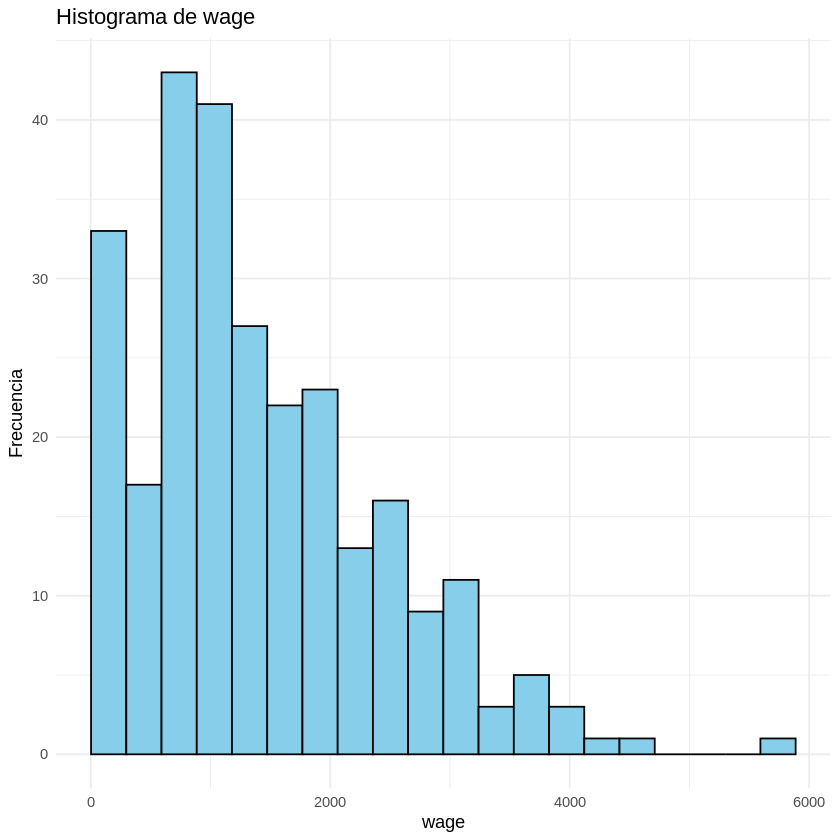

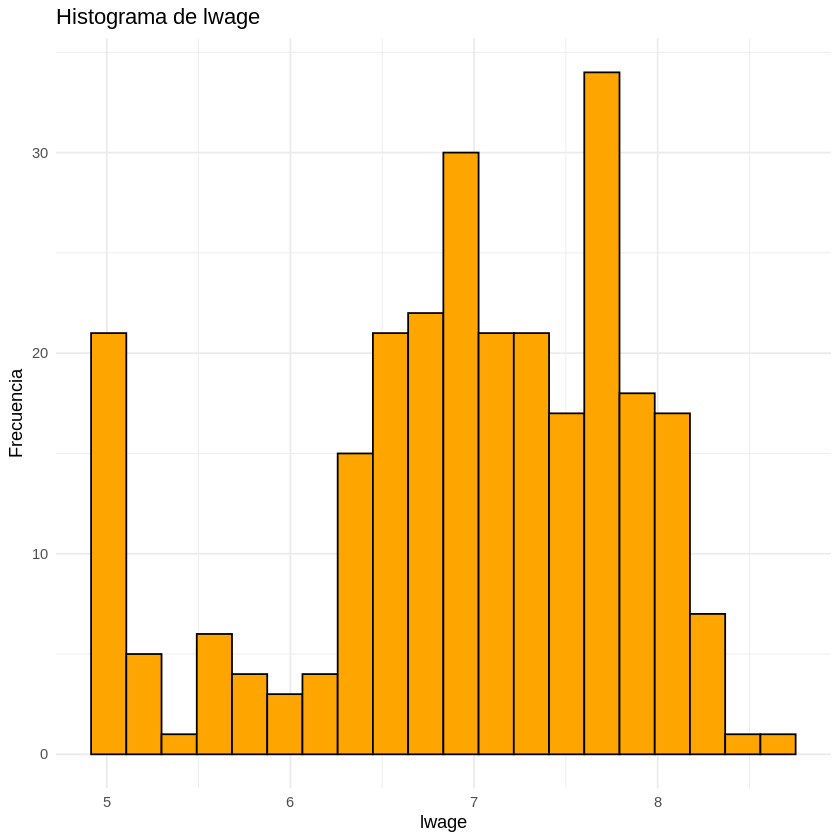

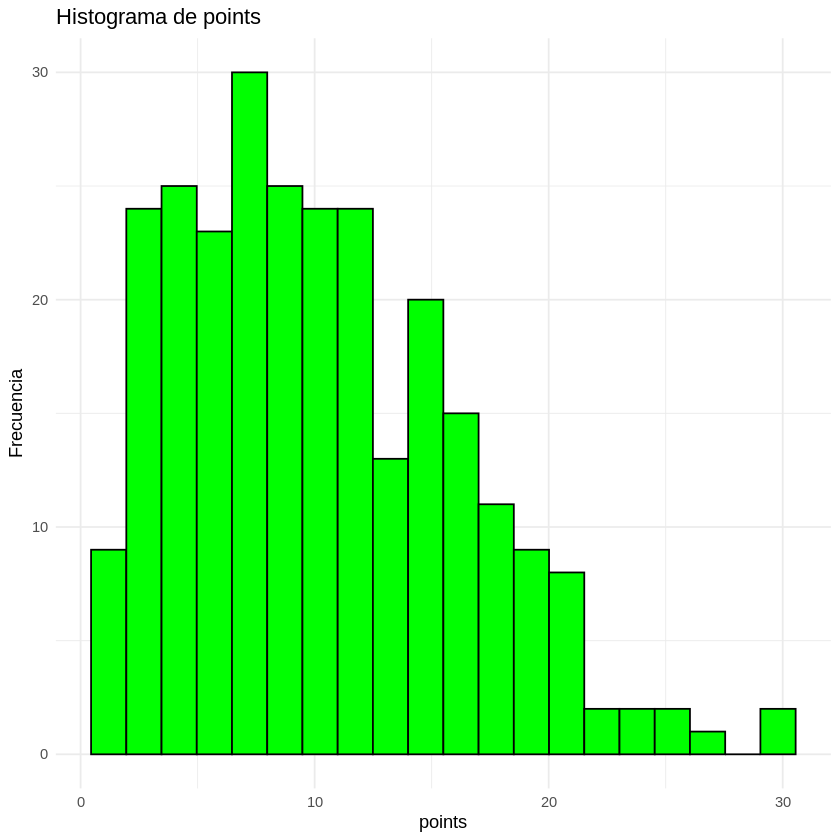

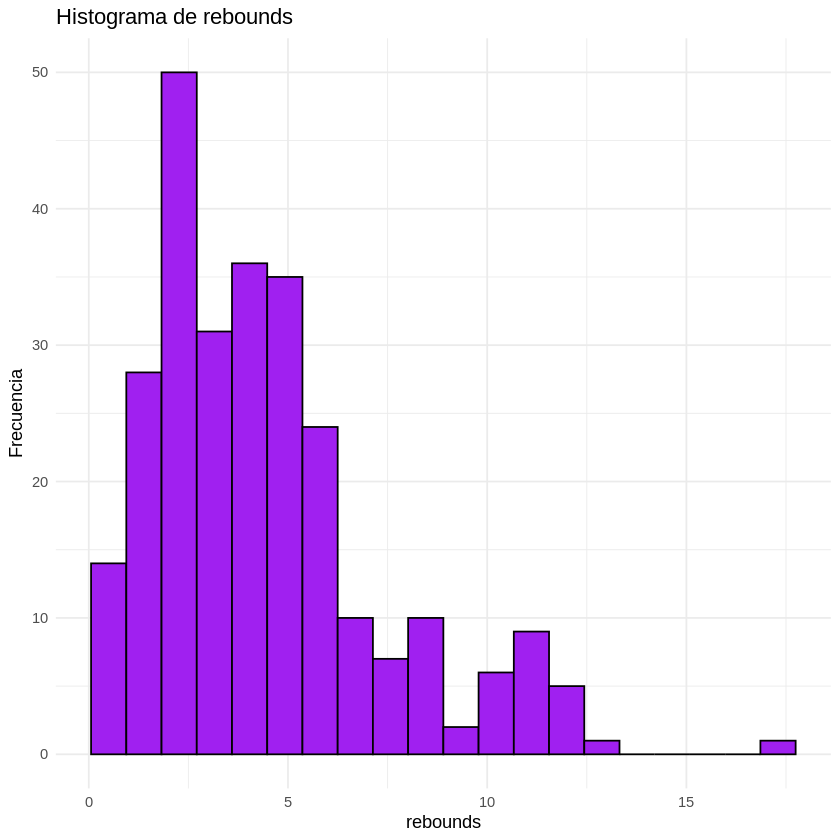

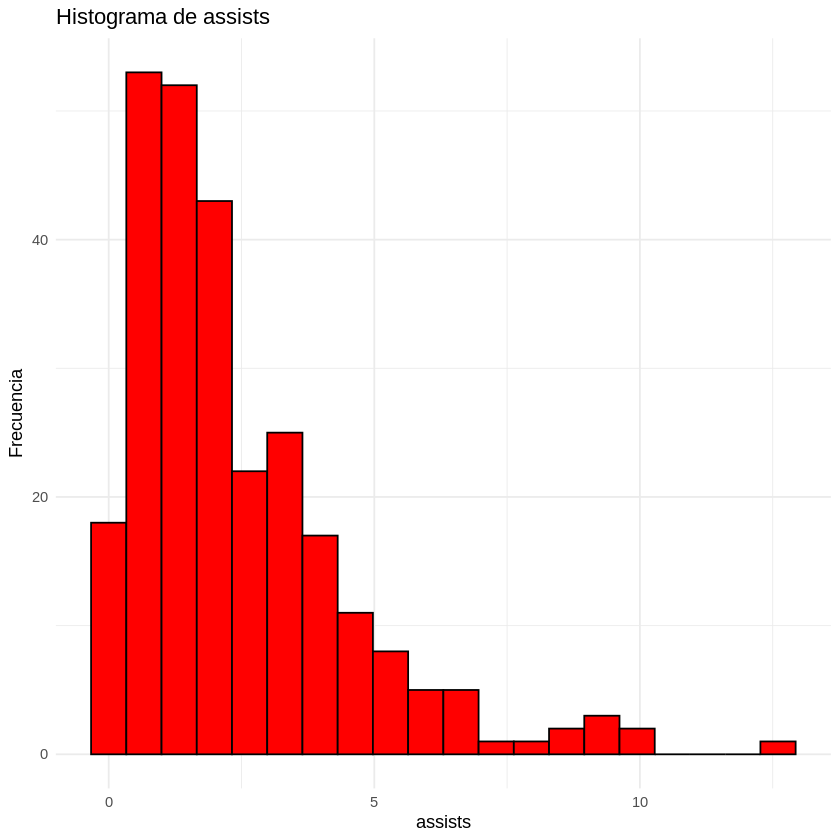

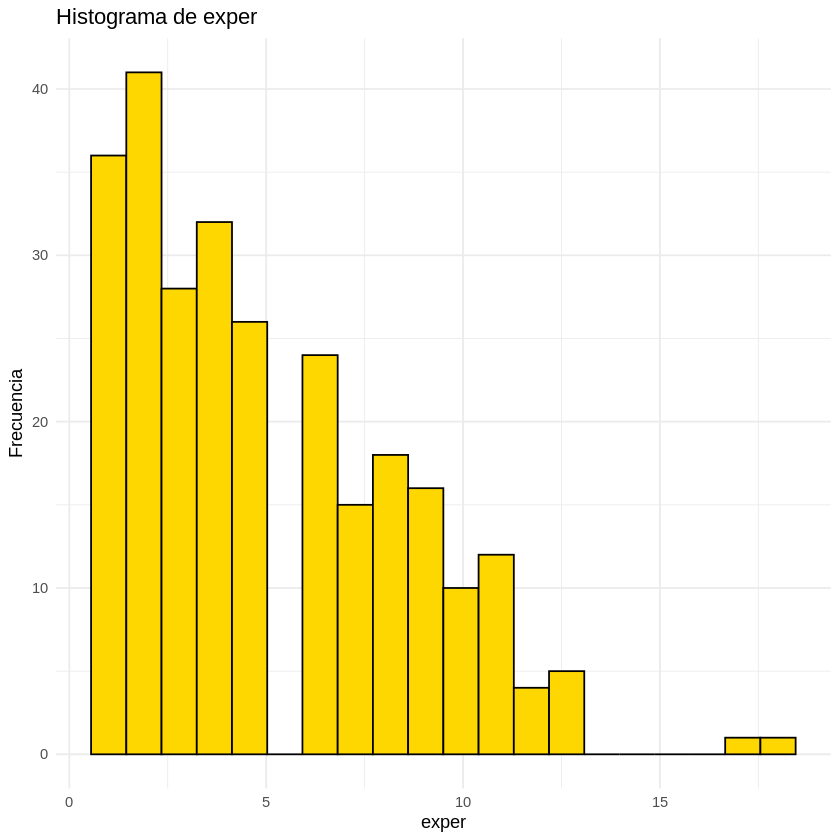

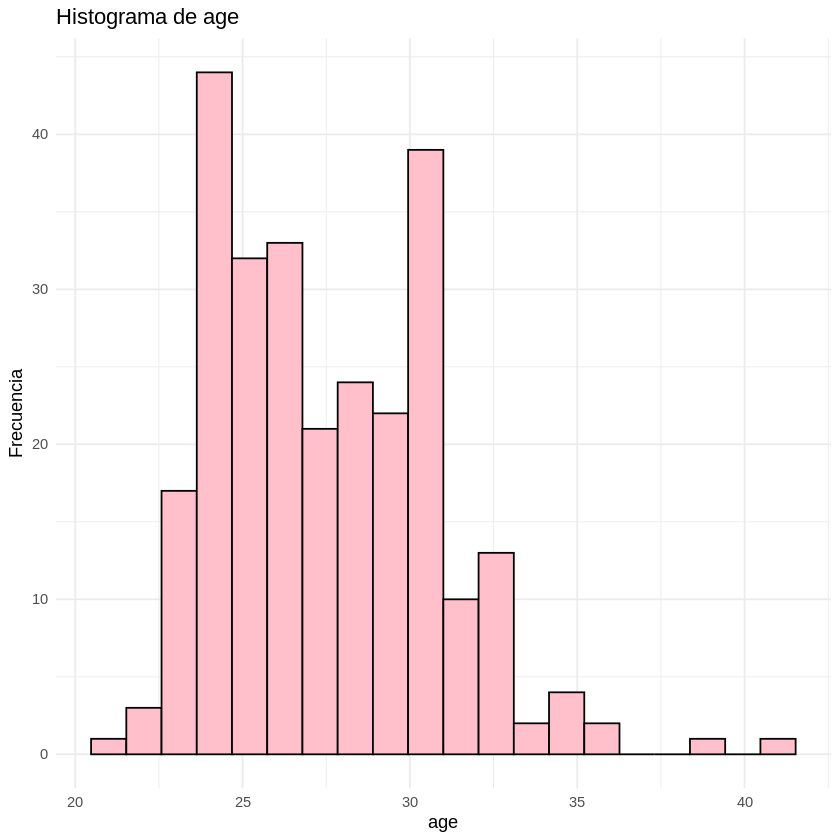

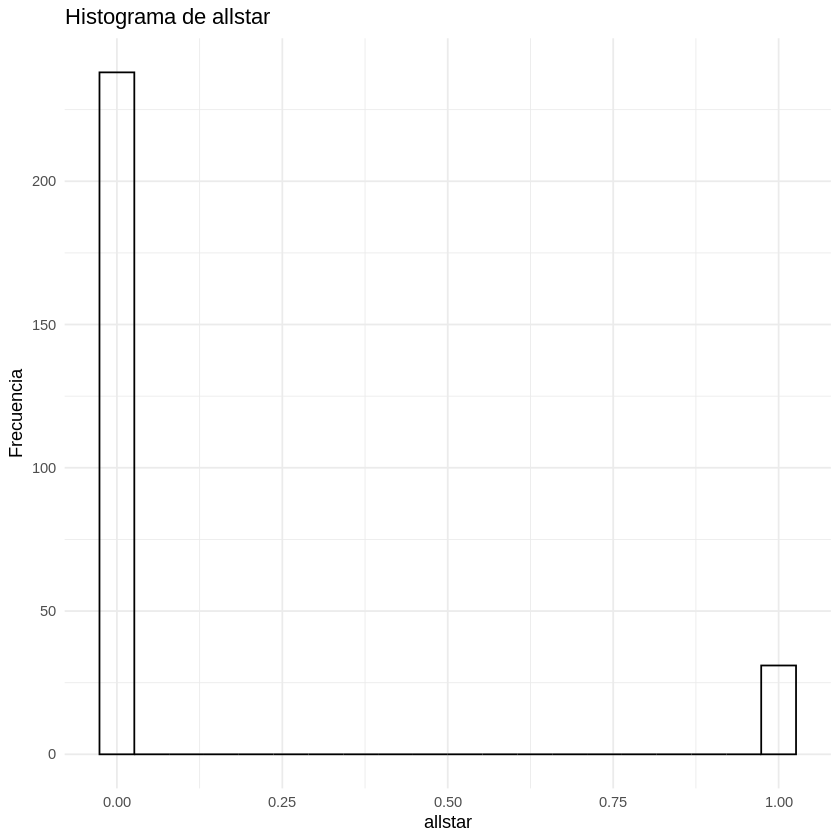

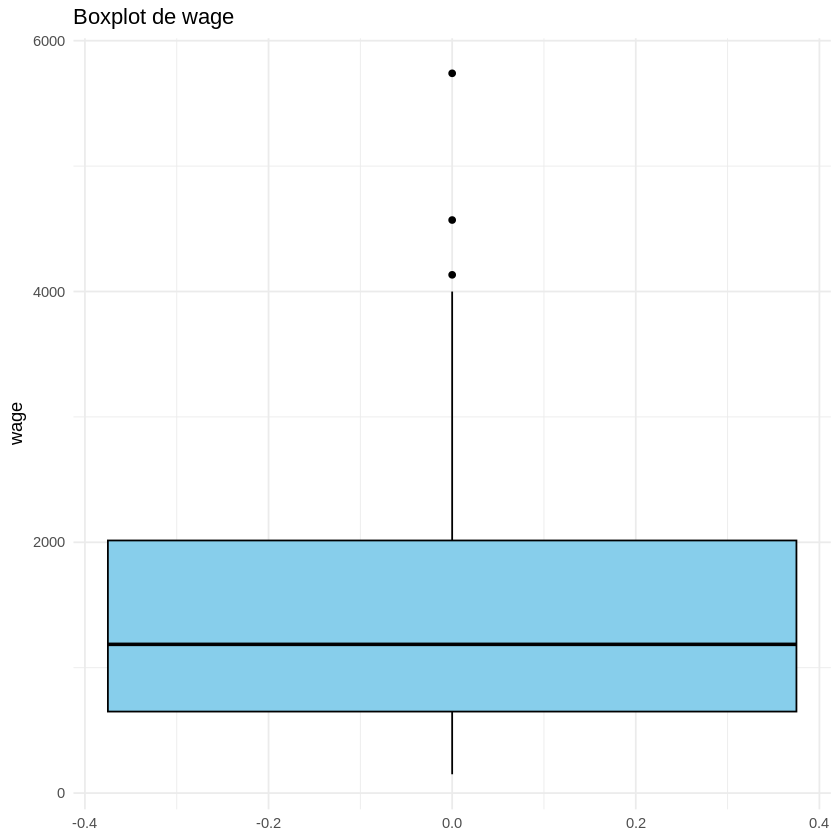

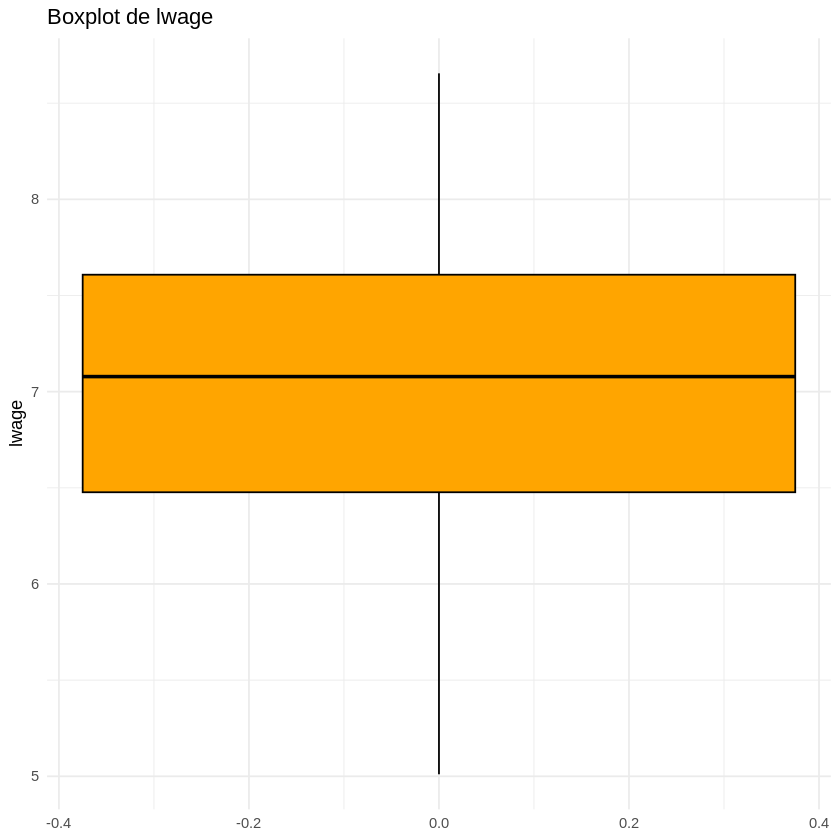

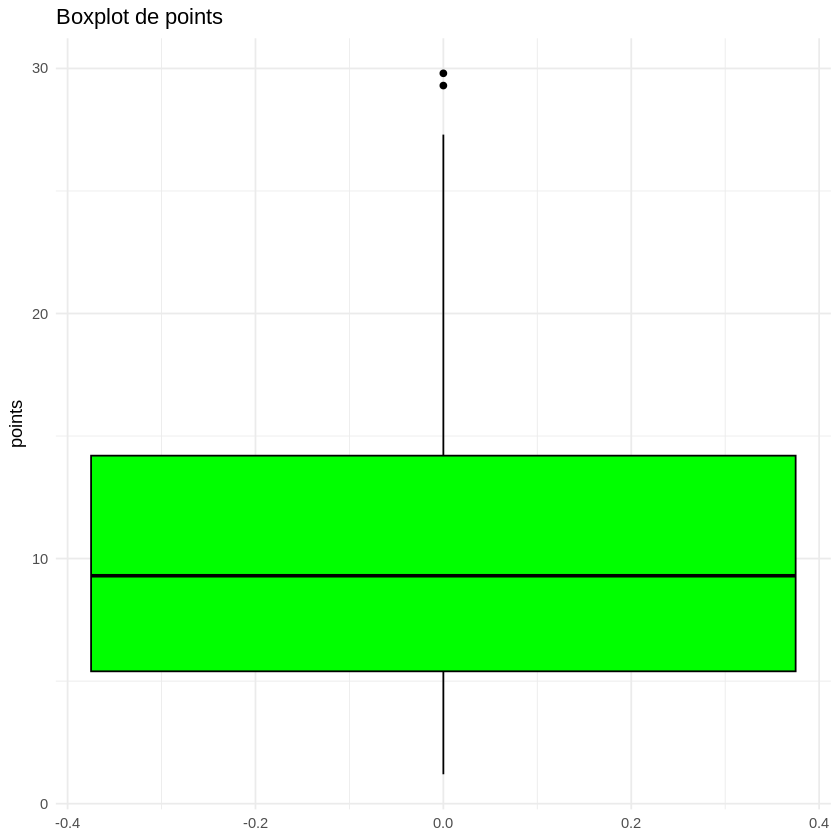

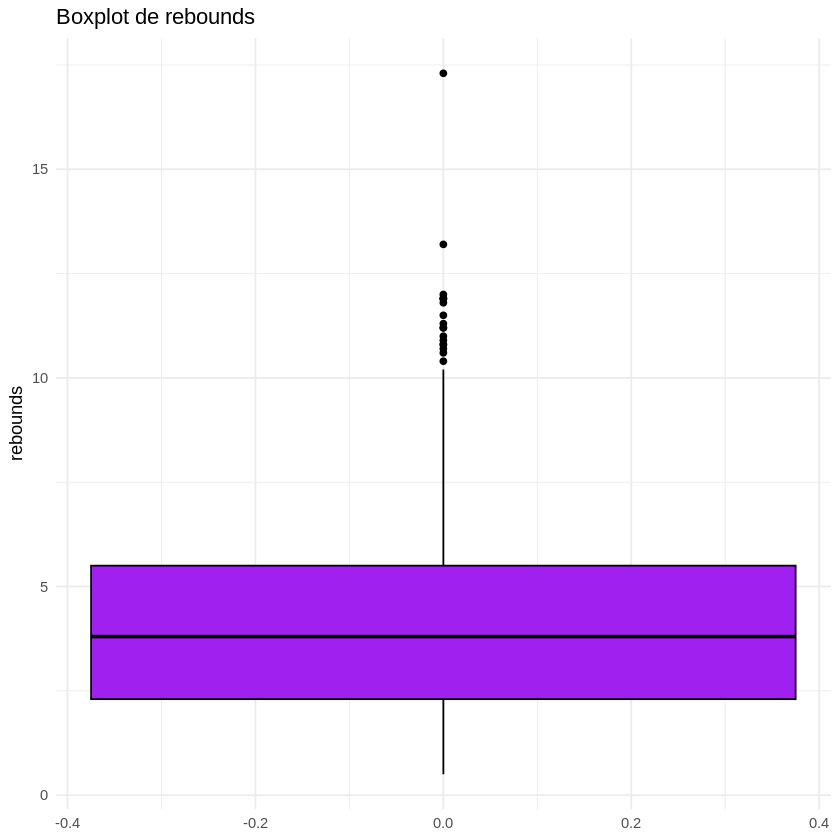

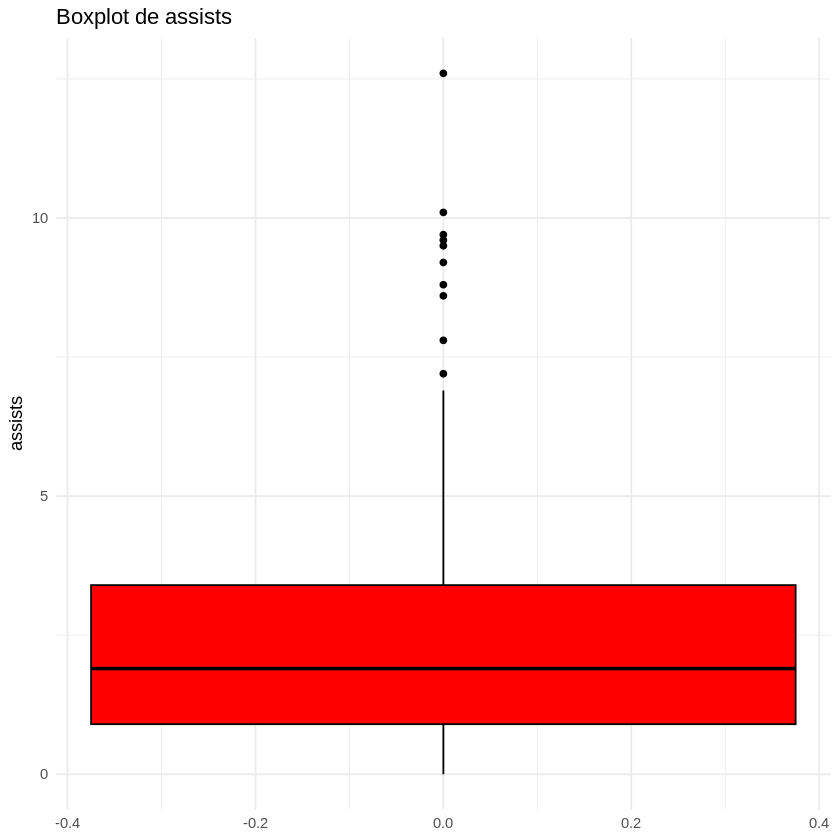

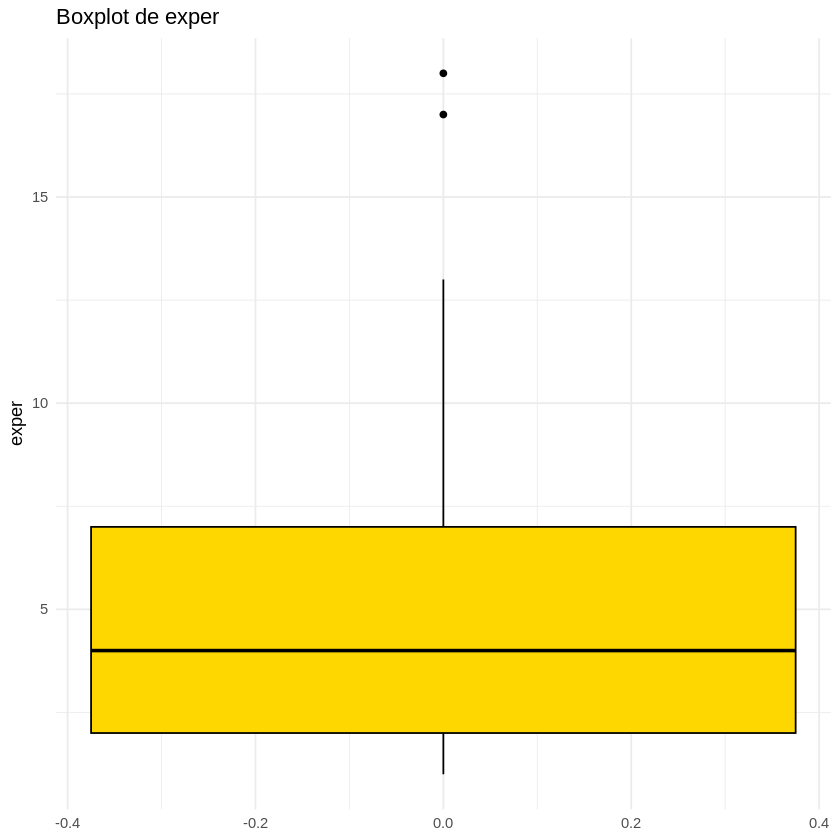

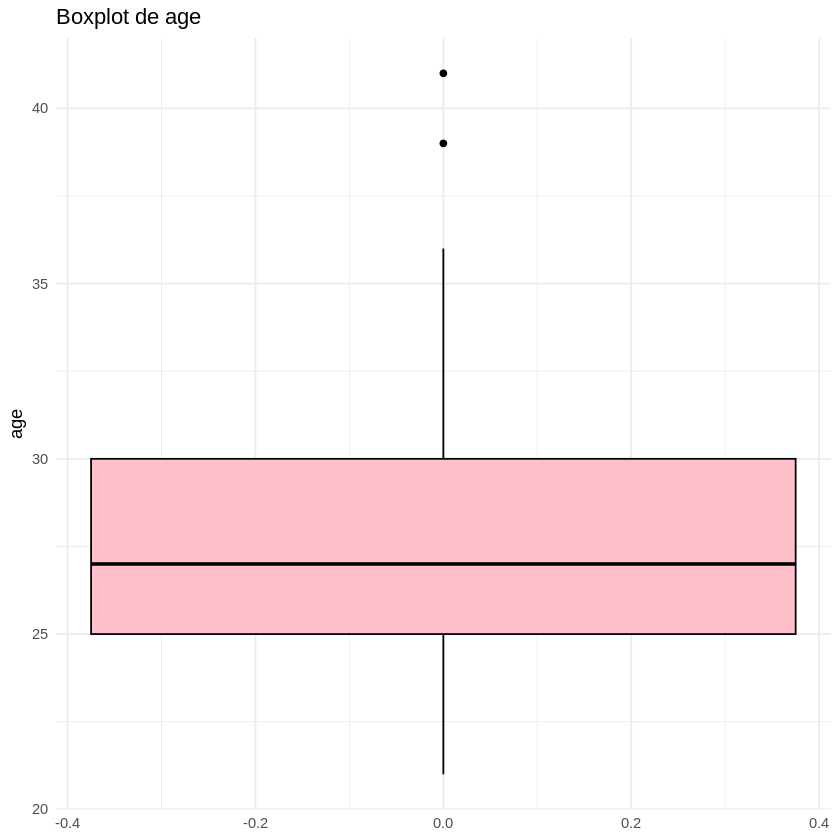

`geom_smooth()` using formula = 'y ~ x'


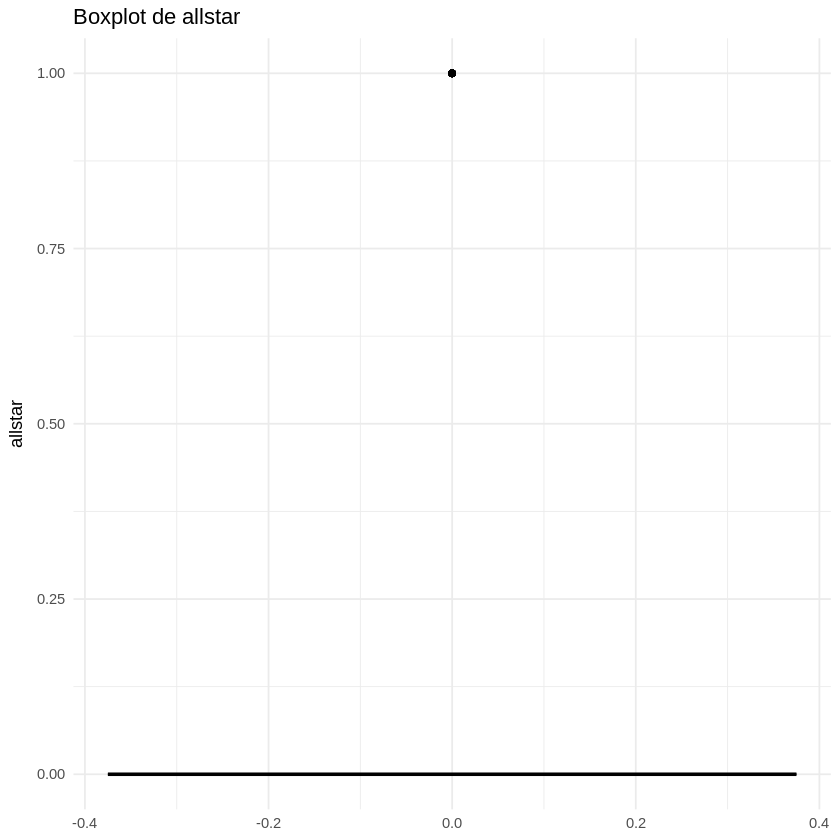

`geom_smooth()` using formula = 'y ~ x'


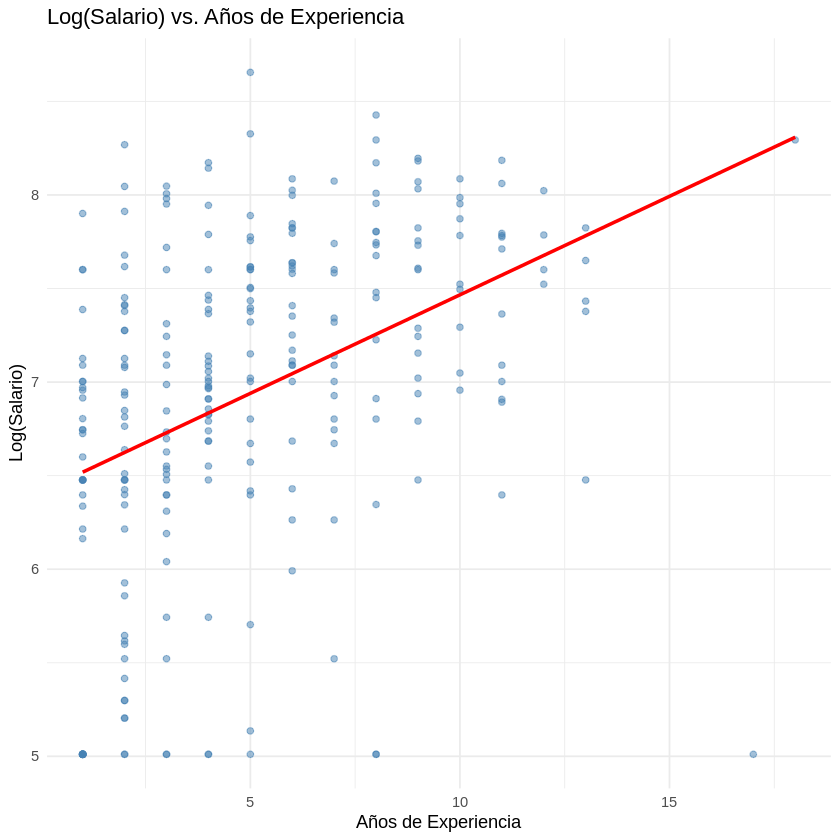

`geom_smooth()` using formula = 'y ~ x'


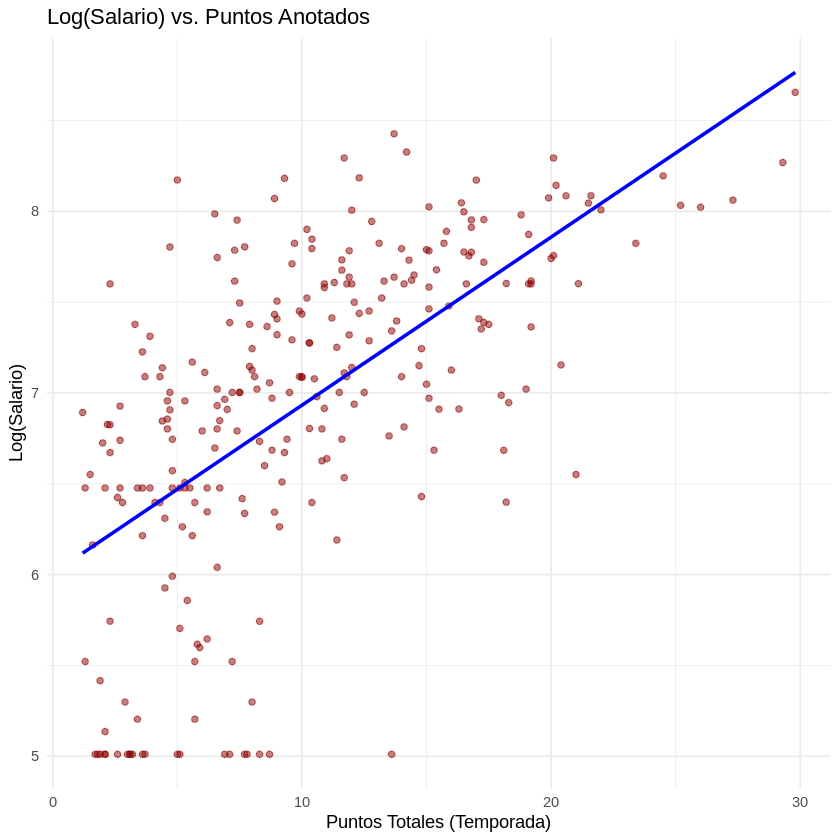

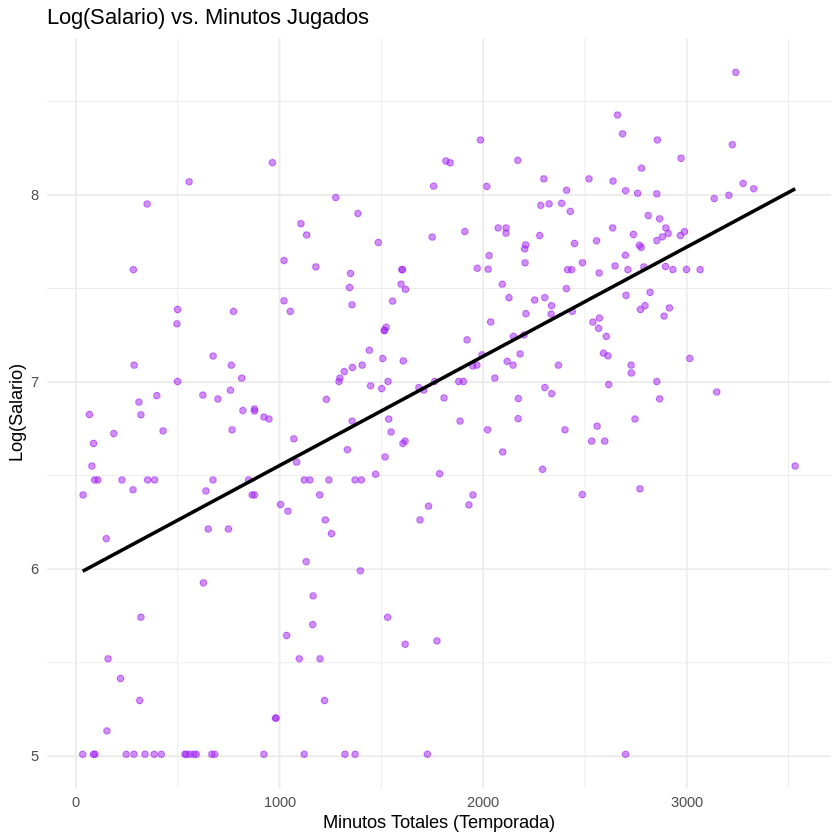

In [26]:
library(dplyr)
library(tidyr)
# Histogramas de las variables principales
colores <- c("skyblue", "orange", "green", "purple", "red", "gold", "pink")

for (i in seq_along(vars_key)) {
  var <- vars_key[i]

  print(
    ggplot(nbasal, aes(x = .data[[var]])) +
      geom_histogram(fill = colores[i], color = "black", bins = 20) +
      labs(
        title = paste("Histograma de", var),
        x = var,
        y = "Frecuencia"
      ) +
      theme_minimal()
  )
}


# Boxplot de las variables principales
for (i in seq_along(vars_key)) {
  var <- vars_key[i]

  print(
    ggplot(nbasal, aes(y = .data[[var]])) +
      geom_boxplot(fill = colores[i], color = "black") +
      labs(
        title = paste("Boxplot de", var),
        y = var
      ) +
      theme_minimal()
  )
}

# Gráfico de dispersión: lwage vs. exper
ggplot(nbasal, aes(x = exper, y = lwage)) +
  geom_point(alpha = 0.5, color = "steelblue") +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  labs(title = "Log(Salario) vs. Años de Experiencia",
       x = "Años de Experiencia", y = "Log(Salario)") +
  theme_minimal()

# Gráfico de dispersión: lwage vs. points
ggplot(nbasal, aes(x = points, y = lwage)) +
  geom_point(alpha = 0.5, color = "darkred") +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  labs(title = "Log(Salario) vs. Puntos Anotados",
       x = "Puntos Totales (Temporada)", y = "Log(Salario)") +
  theme_minimal()

# Gráfico de dispersión: lwage vs. minutes
ggplot(nbasal, aes(x = minutes, y = lwage)) +
  geom_point(alpha = 0.5, color = "purple") +
  geom_smooth(method = "lm", se = FALSE, color = "black") +
  labs(title = "Log(Salario) vs. Minutos Jugados",
       x = "Minutos Totales (Temporada)", y = "Log(Salario)") +
  theme_minimal()

### 4. Planteamiento de las hipótesis de investigación

El objetivo principal de este análisis es entender los determinantes del salario de los jugadores de la NBA. Se plantean las siguientes hipótesis:

*   **Hipótesis 1 (Experiencia):** Se espera que la experiencia en la NBA tenga un efecto positivo sobre el salario, pero con rendimientos decrecientes. Un jugador con más años en la liga acumula reputación y habilidades específicas, pero el declive físico eventualmente reduce su valor de mercado.
    *   `H0: β_exper = 0` (La experiencia no tiene efecto en el salario)
    *   `H1: β_exper > 0` (La experiencia tiene un efecto positivo en el salario)
    *   `H0: β_exper2 = 0` (No hay rendimientos decrecientes)
    *   `H1: β_exper2 < 0` (Existen rendimientos decrecientes de la experiencia)

*   **Hipótesis 2 (Desempeño ofensivo):** Se espera que los jugadores con mayor anotación perciban salarios significativamente más altos. Los puntos son el indicador de productividad más visible y valorado por los equipos y los aficionados.
    *   `H0: β_points = 0` (Los puntos anotados no tienen efecto en el salario)
    *   `H1: β_points > 0` (Anotar más puntos se asocia con mayor salario)

*   **Hipótesis 3 (Efecto conjunto del desempeño en cancha):** Se espera que el conjunto de variables de rendimiento (puntos, rebotes, asistencias) explique de forma conjunta y significativa la variación en el salario, más allá del efecto individual de cada una.
    *   `H0: β_points = β_rebounds = β_assists = 0`
    *   `H1: Al menos uno de los coeficientes es distinto de cero`

### 5. Justificación de la elección de la variable dependiente y explicativas

**Variable Dependiente:**
*   **`lwage` (Logaritmo del salario anual):** Se utiliza el logaritmo natural del salario en lugar del salario bruto por dos razones principales. Primero, la distribución de `wage` es marcadamente asimétrica (sesgo positivo), con algunos contratos extremadamente altos que distorsionan el análisis; el logaritmo corrige este problema, acercando la distribución a la normalidad. Segundo, el modelo log-nivel permite interpretar los coeficientes como efectos **porcentuales** sobre el salario, lo cual es más intuitivo y coherente con la práctica estándar en economía laboral (Ecuación de Mincer).

**Variables Explicativas:**
*   **`points` (Puntos anotados en la temporada):** Es el indicador de productividad ofensiva más relevante en la NBA. Los jugadores con mayor anotación generan más valor para sus franquicias a través de victorias y taquilla, por lo que se espera que el mercado los remunere con salarios más altos.

*   **`rebounds` (Rebotes en la temporada):** Mide la contribución defensiva y de control del balón. Es una habilidad específica especialmente valorada en pívots y aleros.

*   **`assists` (Asistencias en la temporada):** Refleja la capacidad de creación de juego, particularmente apreciada en bases y escoltas. Es un indicador de valor añadido más allá de la anotación directa.

*   **`exper` (Años de experiencia en la NBA):** Siguiendo la teoría del capital humano (Becker, 1964; Mincer, 1974), la experiencia acumula habilidades específicas del trabajo que incrementan la productividad y el valor del jugador. Se espera un efecto positivo sobre el salario.

*   **`age` (Edad del jugador):** Permite capturar efectos del ciclo de vida del jugador. Puede reflejar tanto experiencia acumulada como posibles caídas en el rendimiento físico, por lo que su efecto puede no ser estrictamente lineal.

*   **`allstar` (Jugador All-Star):** Variable dicotómica que toma valor 1 si el jugador ha sido seleccionado como All-Star. Representa un reconocimiento de alto nivel de desempeño y prestigio dentro de la liga. Se espera que tenga un efecto positivo significativo sobre el salario, dado que estos jugadores suelen ser los más valorados en el mercado




### 6. Especificación del modelo de regresión poblacional propuesto

Se propone un modelo de regresión lineal múltiple para estimar el efecto de la experiencia, el desempeño en cancha, la posición y la ubicación en el draft sobre el logaritmo del salario de los jugadores de la NBA. El modelo poblacional se especifica de la siguiente manera:

$$
\ln(\text{wage}_i) = \beta_0 + \beta_1\,\text{points}_i + \beta_2\,\text{rebounds}_i + \beta_3\,\text{assists}_i + \beta_4\,\text{exper}_i + \beta_5\,\text{age}_i + \beta_6\,\text{allstar}_i + u_i
$$

Donde:
*   $\ln(\text{wage}_i)$: Logaritmo natural del salario anual del jugador $i$ (variable dependiente).
*   $\beta_0$: Intercepto, salario esperado en logaritmos cuando todas las variables explicativas son cero.
*   $\text{points}_i$: Puntos anotados por el jugador $i$ durante la temporada.
*   $\beta_1$: Cambio porcentual esperado en el salario por cada punto adicional anotado, ceteris paribus.
*   $\text{rebounds}_i$: Rebotes totales del jugador $i$ en la temporada.
*   $\beta_2$: Cambio porcentual esperado en el salario por cada rebote adicional, ceteris paribus.
*   $\text{assists}_i$: Asistencias totales del jugador $i$ en la temporada.
*   $\beta_3$: Cambio porcentual esperado en el salario por cada asistencia adicional, ceteris paribus.
*   $\text{exper}_i$: Años de experiencia del jugador $i$ en la NBA.
*   $\beta_4$: Efecto marginal inicial de la experiencia sobre el log-salario.
*   $\text{age}_i$: Edad del jugador.
*   $\beta_5$: Efecto de la edad sobre el salario.
*   $\text{allstar}_i$: Variable dummy que toma valor 1 si el jugador fue All-Star.
*   $\beta_6$: Diferencia porcentual en el salario asociada a ser All-Star.
*   $u_i$: Término de error que recoge todos los factores no observados que afectan el salario del jugador $i$.